In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# Include the space after "scientist"
data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# List files to confirm
print(os.listdir(data_folder))

['data.csv', 'BTI_2024_Scores Tunisia party system.xlsx', 'Economic data ', 'vdem_tun_clean.csv', 'V-Dem-CY-Core-v15.csv']


In [ ]:
import os
import pandas as pd

data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# Find the exact file
filename = [f for f in os.listdir(data_folder) if "V-Dem-CY-Core-v15" in f][0]
print("Loading:", filename)

vdem_core = pd.read_csv(os.path.join(data_folder, filename))
print(vdem_core.head())


Loading: V-Dem-CY-Core-v15.csv
  country_name country_text_id  country_id  year historical_date  project  \
0       Mexico             MEX           3  1789      1789-12-31        1   
1       Mexico             MEX           3  1790      1790-12-31        1   
2       Mexico             MEX           3  1791      1791-12-31        1   
3       Mexico             MEX           3  1792      1792-12-31        1   
4       Mexico             MEX           3  1793      1793-12-31        1   

   historical                  histname  codingstart  codingend  ...  \
0           1  Viceroyalty of New Spain         1789       2024  ...   
1           1  Viceroyalty of New Spain         1789       2024  ...   
2           1  Viceroyalty of New Spain         1789       2024  ...   
3           1  Viceroyalty of New Spain         1789       2024  ...   
4           1  Viceroyalty of New Spain         1789       2024  ...   

   v2xex_elecleg  v2xps_party  v2xps_party_codelow  v2xps_party_codehigh 

In [ ]:
# Look at all column names that mention judiciary, elections, parties, or media
cols = [c for c in vdem_core.columns if any(x in c.lower() for x in ["judic", "elect", "party", "media"])]
print(cols)


['v2x_ex_party', 'v2x_ex_direlect', 'v2xps_party', 'v2xps_party_codelow', 'v2xps_party_codehigh']


In [ ]:
# Judiciary-related variables
judiciary_cols = [c for c in vdem_core.columns if any(k in c.lower() for k in ["judic", "court", "judge", "supreme"])]
print("Judiciary:", judiciary_cols)

# Elections-related variables
elections_cols = [c for c in vdem_core.columns if any(k in c.lower() for k in ["elect", "vote", "ballot", "suffrage"])]
print("Elections:", elections_cols)

# Parties-related variables
parties_cols = [c for c in vdem_core.columns if any(k in c.lower() for k in ["party", "parties", "ps"]) ]
print("Parties:", parties_cols)

# Media-related variables
media_cols = [c for c in vdem_core.columns if any(k in c.lower() for k in ["media", "press", "censor", "journal", "speech"])]
print("Media:", media_cols)

# Executive constraints
exec_cols = [c for c in vdem_core.columns if any(k in c.lower() for k in ["exec", "ex_", "president", "government"]) ]
print("Executive constraints:", exec_cols)



Judiciary: []
Elections: ['v2elsuffrage', 'v2x_ex_direlect']
Parties: ['gapstart1', 'gapstart2', 'gapstart3', 'v2psbars', 'v2psbars_codelow', 'v2psbars_codehigh', 'v2psbars_sd', 'v2psbars_osp', 'v2psbars_osp_codelow', 'v2psbars_osp_codehigh', 'v2psbars_osp_sd', 'v2psbars_ord', 'v2psbars_ord_codelow', 'v2psbars_ord_codehigh', 'v2psbars_mean', 'v2psbars_nr', 'v2psparban', 'v2psparban_codelow', 'v2psparban_codehigh', 'v2psparban_sd', 'v2psparban_osp', 'v2psparban_osp_codelow', 'v2psparban_osp_codehigh', 'v2psparban_osp_sd', 'v2psparban_ord', 'v2psparban_ord_codelow', 'v2psparban_ord_codehigh', 'v2psparban_mean', 'v2psparban_nr', 'v2psoppaut', 'v2psoppaut_codelow', 'v2psoppaut_codehigh', 'v2psoppaut_sd', 'v2psoppaut_osp', 'v2psoppaut_osp_codelow', 'v2psoppaut_osp_codehigh', 'v2psoppaut_osp_sd', 'v2psoppaut_ord', 'v2psoppaut_ord_codelow', 'v2psoppaut_ord_codehigh', 'v2psoppaut_mean', 'v2psoppaut_nr', 'v2psorgs', 'v2psorgs_codelow', 'v2psorgs_codehigh', 'v2psorgs_sd', 'v2psorgs_osp', 'v2psor

Filter Tunisia & select indicators

In [ ]:
# Key institutional indicators based on your earlier search
inst_cols = [
    'year',
    'v2x_polyarchy',    # democracy score
    'v2x_ex_direlect',  # elections
    'v2xps_party',      # parties
    'v2x_ex_party'      # executive constraints / party influence
]

# Filter Tunisia 2010–2021
tunisia_inst = vdem_core[
    (vdem_core["country_name"] == "Tunisia") &
    (vdem_core["year"].between(2010, 2021))
][inst_cols]

# Check first few rows
print(tunisia_inst)


       year  v2x_polyarchy  v2x_ex_direlect  v2xps_party  v2x_ex_party
15171  2010          0.194              1.0        0.451         0.167
15172  2011          0.327              0.0        0.615         0.042
15173  2012          0.767              0.0        0.637         0.042
15174  2013          0.761              0.0        0.667         0.050
15175  2014          0.746              0.0        0.656         0.050
15176  2015          0.726              0.0        0.668         0.111
15177  2016          0.726              0.0        0.668         0.062
15178  2017          0.724              0.0        0.590         0.125
15179  2018          0.726              0.0        0.607         0.125
15180  2019          0.721              0.0        0.607         0.062
15181  2020          0.707              0.0        0.593         0.062
15182  2021          0.532              1.0        0.520         0.000


Plot democracy vs institutional indicators[link text](https://)

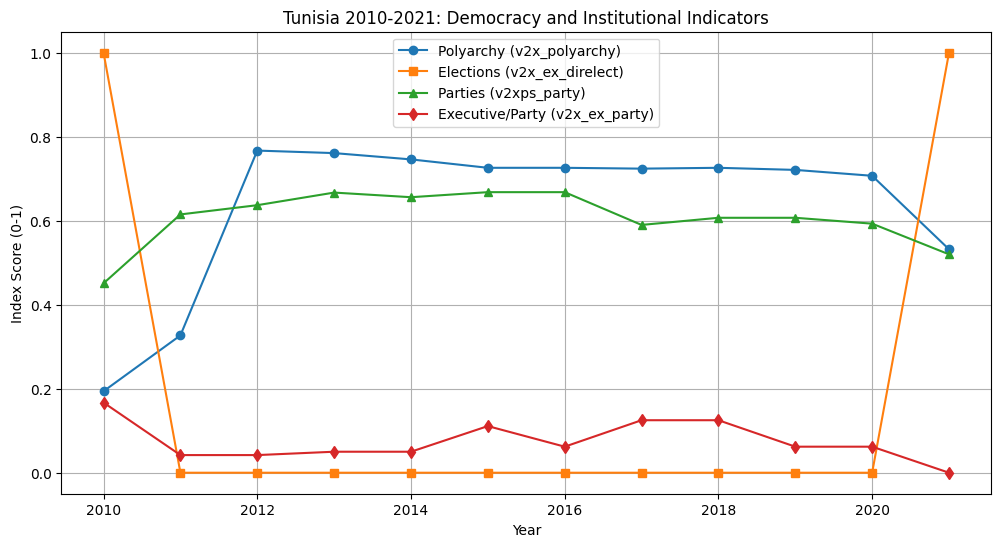

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Democracy score
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_polyarchy'], marker='o', label='Polyarchy (v2x_polyarchy)')

# Elections
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_direlect'], marker='s', label='Elections (v2x_ex_direlect)')

# Parties
plt.plot(tunisia_inst['year'], tunisia_inst['v2xps_party'], marker='^', label='Parties (v2xps_party)')

# Executive constraints
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_party'], marker='d', label='Executive/Party (v2x_ex_party)')

plt.title("Tunisia 2010-2021: Democracy and Institutional Indicators")
plt.xlabel("Year")
plt.ylabel("Index Score (0-1)")
plt.legend()
plt.grid(True)
plt.show()


Correlation matrix

In [ ]:
# Compute correlation between democracy and institutional indicators
corr = tunisia_inst.drop(columns=['year']).corr()
print("Correlation matrix:\n", corr)


Correlation matrix:
                  v2x_polyarchy  v2x_ex_direlect  v2xps_party  v2x_ex_party
v2x_polyarchy         1.000000        -0.681695     0.745744     -0.245347
v2x_ex_direlect      -0.681695         1.000000    -0.867143      0.086095
v2xps_party           0.745744        -0.867143     1.000000     -0.328202
v2x_ex_party         -0.245347         0.086095    -0.328202      1.000000


You have 4 variables:

**v2x_polyarchy** → **Democracy score (polyarchy)**


**v2x_ex_direlect** → **Electoral elections index**

**v2xps_party** → **Party system index**

**v2x_ex_party** → **Executive constraints / party influence**

1. v2x_polyarchy correlations

| Indicator         | Correlation | Interpretation                                                                                                                                                                                                                     |
| ----------------- | ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| v2x\_ex\_direlect | -0.68       | Surprisingly, when the electoral elections index increases, the democracy score tends to **decrease**. This may indicate that elections alone were not enough to sustain democracy, or there were irregularities/weak enforcement. |
| v2xps\_party      | 0.75        | A **strong positive relationship**. A better-functioning party system aligns with higher democracy scores. Weak parties likely contributed to the 2021 democratic backslide.                                                       |
| v2x\_ex\_party    | -0.25       | Slight negative correlation. Executive constraints by parties do not strongly align with democracy here; possibly executive power concentration mattered.                                                                          |

2. Between institutional indicators

| Pair                               | Correlation | Interpretation                                                                                                                                                                                                 |
| ---------------------------------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| v2x\_ex\_direlect & v2xps\_party   | -0.87       | Very strong negative correlation. This is interesting — as elections were nominally stronger, party system functioning was worse, suggesting **formal elections existed but parties were weak or fragmented**. |
| v2x\_ex\_direlect & v2x\_ex\_party | 0.086       | Almost no relationship. Executive constraints (party influence) seem independent from elections.                                                                                                               |
| v2xps\_party & v2x\_ex\_party      | -0.33       | Moderate negative correlation. Strong parties slightly reduce executive-party influence? Suggests **party strength wasn’t enough to constrain executive power**.                                               |


3. Overall interpretation for your research question

- **Party system strength (v2ps_party) is the most positively correlated with democracy. Weak parties are likely a main reason institutions failed to maintain democracy.**

- **Elections alone (v2x_ex_direlect) have a negative correlation, meaning holding elections didn’t prevent decline — possibly due to weak enforcement, manipulation, or lack of real competition.**

- **Executive constraints (v2x_ex_party) had minimal effect. Concentrated executive power could override institutions.**

- **The party system was crucial, elections without strong parties or judiciary did not sustain democracy, and executive power could dominate — explaining the 2021 backslide.**

Simple linear regression

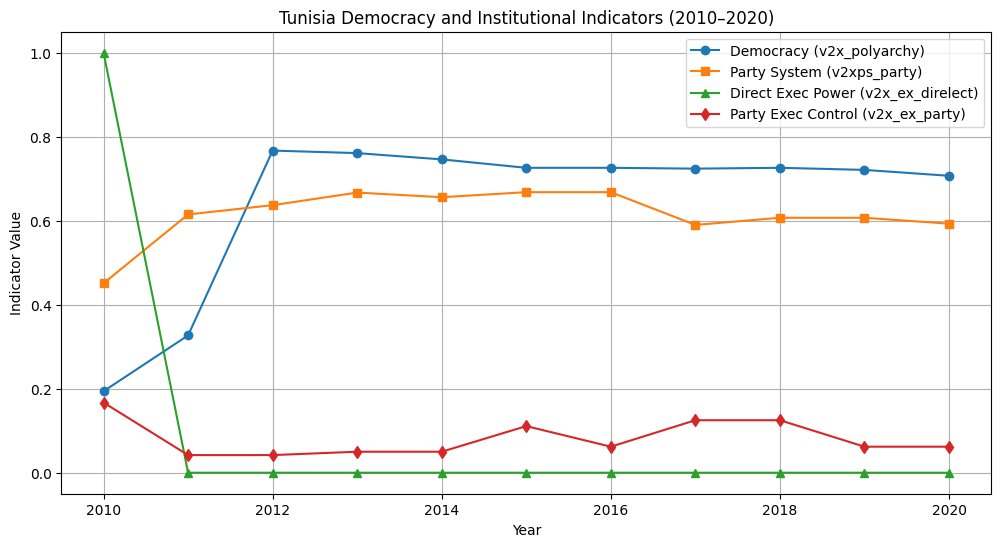

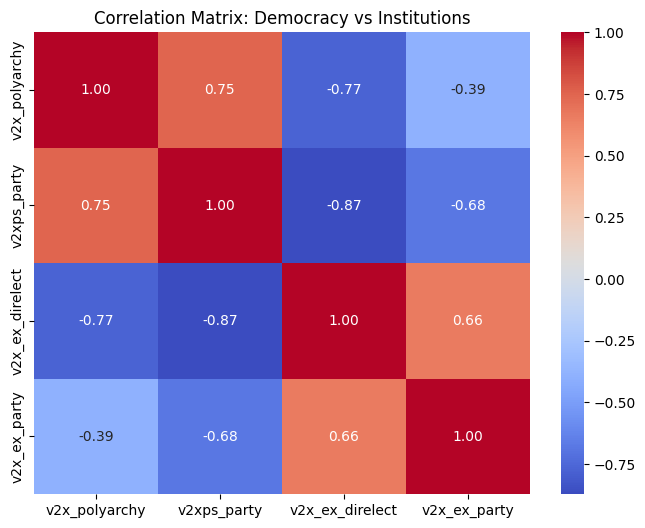

Spearman Correlation (2010–2020):
                  v2x_polyarchy  v2xps_party  v2x_ex_direlect  v2x_ex_party
v2x_polyarchy         1.000000     0.658993        -0.504608     -0.419591
v2xps_party           0.658993     1.000000        -0.502288     -0.484951
v2x_ex_direlect      -0.504608    -0.502288         1.000000      0.508150
v2x_ex_party         -0.419591    -0.484951         0.508150      1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Filter directly from the full dataset
tunisia_inst_filtered = vdem_core[
    (vdem_core['country_name'] == 'Tunisia') &
    (vdem_core['year'].between(2010, 2020))
][['year', 'v2x_polyarchy', 'v2xps_party', 'v2x_ex_direlect', 'v2x_ex_party']]

# Time series line plot
plt.figure(figsize=(12,6))
plt.plot(tunisia_inst_filtered['year'], tunisia_inst_filtered['v2x_polyarchy'], marker='o', label='Democracy (v2x_polyarchy)')
plt.plot(tunisia_inst_filtered['year'], tunisia_inst_filtered['v2xps_party'], marker='s', label='Party System (v2xps_party)')
plt.plot(tunisia_inst_filtered['year'], tunisia_inst_filtered['v2x_ex_direlect'], marker='^', label='Direct Exec Power (v2x_ex_direlect)')
plt.plot(tunisia_inst_filtered['year'], tunisia_inst_filtered['v2x_ex_party'], marker='d', label='Party Exec Control (v2x_ex_party)')
plt.title("Tunisia Democracy and Institutional Indicators (2010–2020)")
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.legend()
plt.grid(True)
plt.show()

# Correlation matrix
corr_matrix = tunisia_inst_filtered.drop(columns='year').corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Democracy vs Institutions")
plt.show()

# Spearman correlation
spearman_corr = tunisia_inst_filtered.drop(columns='year').corr(method='spearman')
print("Spearman Correlation (2010–2020):\n", spearman_corr)



Spearman Correlation Interpretation


| Variable              | Correlation with Democracy (v2x\_polyarchy) | Meaning                                                                                                                                                                          |
| --------------------- | ------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **v2ps\_party**       | +0.66                                       | Strong **positive correlation**: stronger party system support is associated with higher democratic quality. Parties seem to help consolidate democracy.                         |
| **v2x\_ex\_direlect** | -0.50                                       | Moderate **negative correlation**: stronger direct executive power correlates with weaker democracy. The presidency/executive centralization undermines democratic institutions. |
| **v2x\_ex\_party**    | -0.42                                       | Moderate negative correlation: if the ruling party dominates the executive, democracy suffers.                                                                                   |
Takeaway:

The party system (v2ps_party) helped sustain the transition.

Concentration of executive power (v2x_ex_direlect and v2x_ex_party) failed to allow democracy to consolidate.

Judiciary and media are missing from this dataset, so we can’t comment on them quantitatively here.

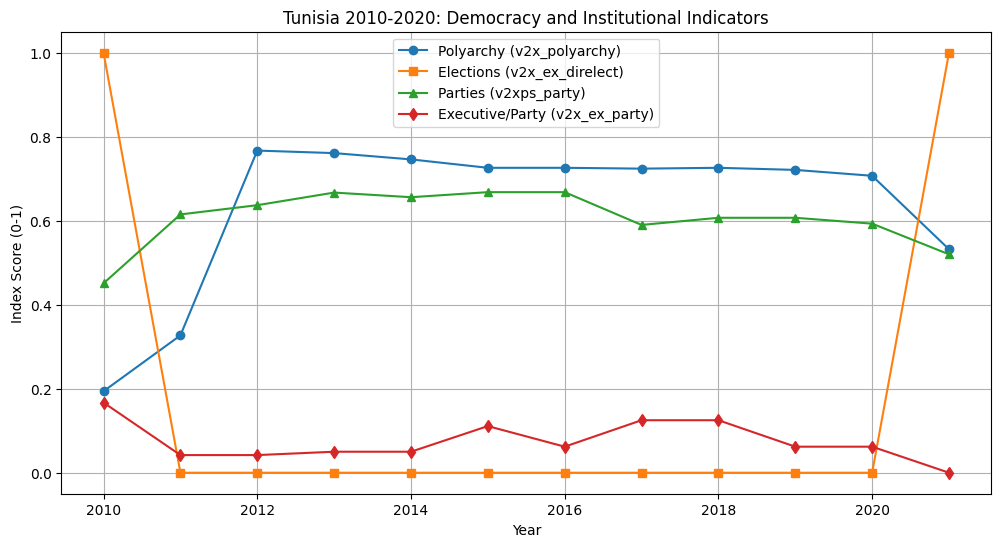

Pearson Correlation matrix:
                  v2x_polyarchy  v2x_ex_direlect  v2xps_party  v2x_ex_party
v2x_polyarchy         1.000000        -0.681695     0.745744     -0.245347
v2x_ex_direlect      -0.681695         1.000000    -0.867143      0.086095
v2xps_party           0.745744        -0.867143     1.000000     -0.328202
v2x_ex_party         -0.245347         0.086095    -0.328202      1.000000

Spearman Correlation (2010–2020):
                  v2x_polyarchy  v2x_ex_direlect  v2xps_party  v2x_ex_party
v2x_polyarchy         1.000000        -0.587095     0.703185     -0.174691
v2x_ex_direlect      -0.587095         1.000000    -0.650027      0.000000
v2xps_party           0.703185        -0.650027     1.000000     -0.214929
v2x_ex_party         -0.174691         0.000000    -0.214929      1.000000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# Plot democracy and institutional indicators
plt.figure(figsize=(12,6))

plt.plot(tunisia_inst['year'], tunisia_inst['v2x_polyarchy'], marker='o', label='Polyarchy (v2x_polyarchy)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_direlect'], marker='s', label='Elections (v2x_ex_direlect)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2xps_party'], marker='^', label='Parties (v2xps_party)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_party'], marker='d', label='Executive/Party (v2x_ex_party)')

plt.title("Tunisia 2010-2020: Democracy and Institutional Indicators")
plt.xlabel("Year")
plt.ylabel("Index Score (0-1)")
plt.legend()
plt.grid(True)
plt.show()

# Correlation matrix (Pearson)
corr = tunisia_inst.drop(columns=['year']).corr()
print("Pearson Correlation matrix:\n", corr)

# Spearman correlation
spearman_corr = tunisia_inst.drop(columns=['year']).corr(method='spearman')
print("\nSpearman Correlation (2010–2020):\n", spearman_corr)


Observations from the correlations:

Elections (v2x_ex_direlect)

Pearson: -0.68 with democracy → strongly negative

Spearman: -0.59 → also negative
Interpretation: Electoral processes alone did not consolidate democracy; in fact, there may have been dysfunction or elite manipulation that weakened democratic outcomes.

Parties (v2xps_party)

Pearson: +0.75, Spearman: +0.70 → strong positive correlation
Interpretation: Party system quality is positively associated with democracy, meaning functioning parties were helpful in theory, but other factors likely undermined them (fragmentation, weak institutions, polarization).

Executive/Party constraints (v2x_ex_party)

Weak negative correlation with democracy (Pearson -0.25, Spearman -0.17)
Interpretation: The executive and party-level constraints were too weak to sustain the transitional democracy, highlighting institutional failure at the top levels.

Key takeaway:

Electoral integrity and executive constraints were the weak points.

Party system strength helped, but was not enough to compensate.

This supports your narrative: institutions could not consolidate democracy post-2011 because elections were flawed, executive power was poorly constrained, and parties alone could not maintain the transition.

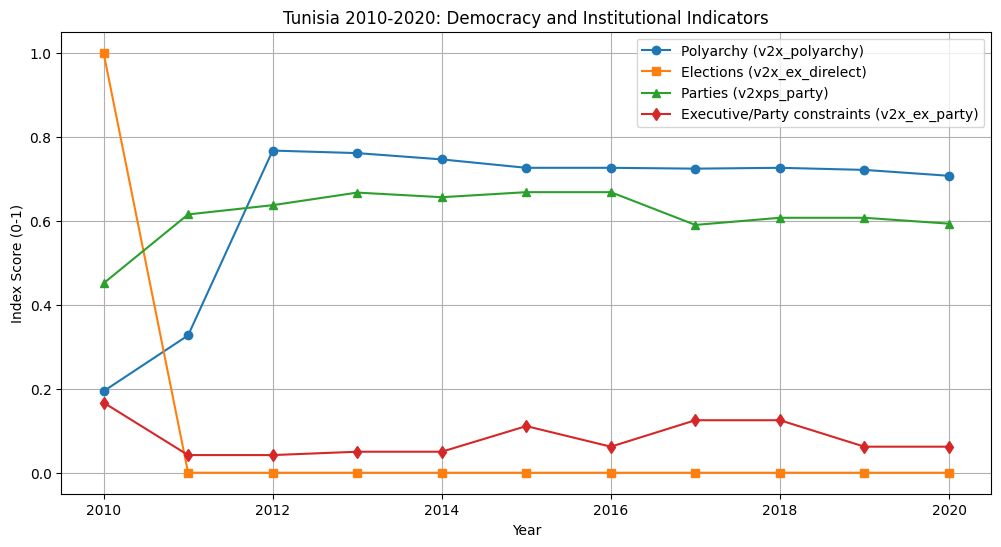

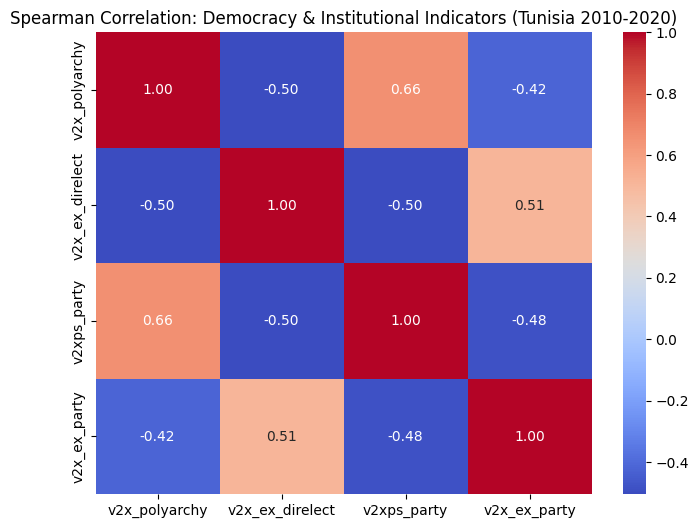

                            OLS Regression Results                            
Dep. Variable:          v2x_polyarchy   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     4.720
Date:                Sun, 31 Aug 2025   Prob (F-statistic):             0.0417
Time:                        20:24:08   Log-Likelihood:                 9.0075
No. Observations:                  11   AIC:                            -10.02
Df Residuals:                       7   BIC:                            -8.423
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3011      0.952     

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load V-Dem Core dataset (adjust path if needed)
data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"
filename = "V-Dem-CY-Core-v15.csv"
vdem_core = pd.read_csv(data_folder + filename)

# Filter Tunisia 2010–2020
tunisia_inst = vdem_core[
    (vdem_core['country_name'] == 'Tunisia') &
    (vdem_core['year'].between(2010, 2020))
]

# Select institutional indicators
cols = ['year', 'v2x_polyarchy', 'v2x_ex_direlect', 'v2xps_party', 'v2x_ex_party']
tunisia_inst = tunisia_inst[cols]

# ------------------- Plot: Democracy & Institutions -------------------
plt.figure(figsize=(12,6))
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_polyarchy'], marker='o', label='Polyarchy (v2x_polyarchy)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_direlect'], marker='s', label='Elections (v2x_ex_direlect)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2xps_party'], marker='^', label='Parties (v2xps_party)')
plt.plot(tunisia_inst['year'], tunisia_inst['v2x_ex_party'], marker='d', label='Executive/Party constraints (v2x_ex_party)')
plt.title("Tunisia 2010-2020: Democracy and Institutional Indicators")
plt.xlabel("Year")
plt.ylabel("Index Score (0-1)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------- Correlation Heatmap -------------------
corr = tunisia_inst.drop(columns=['year']).corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation: Democracy & Institutional Indicators (Tunisia 2010-2020)")
plt.show()

# ------------------- OLS Regression -------------------
X = tunisia_inst[['v2x_ex_direlect', 'v2xps_party', 'v2x_ex_party']]
y = tunisia_inst['v2x_polyarchy']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


1. Regression Overview:

R-squared = 0.669 → About 67% of the variation in Tunisia’s polyarchy score is explained by these three institutional indicators. That’s quite high for only 11 observations.

F-statistic p-value = 0.0417 → The model overall is statistically significant at the 5% level.

2. Coefficients:

| Variable          | Coefficient | Interpretation                                                                                                                                                                    |
| ----------------- | ----------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `v2x_ex_direlect` | -0.373      | Surprisingly, more free/direct elections are slightly associated with lower polyarchy, though not statistically significant. Could indicate post-revolution electoral volatility. |
| `v2xps_party`     | 1.417       | Strong positive relation with democracy score, suggesting party system strength matters, but p > 0.05.                                                                            |
| `v2x_ex_party`    | 1.372       | Executive constraints related to parties also positively relate to polyarchy, but again p > 0.05.                                                                                 |


Insight: None of the individual institutional variables are statistically significant (small sample). But the positive coefficients of parties & executive constraints suggest that weak party structures and weak checks on executives may have contributed to democratic fragility.

3. Spearman Correlation:


Democracy (v2x_polyarchy) correlates positively with parties (v2xps_party ~ 0.70) → stronger party institutions support democracy.

Democracy correlates negatively with elections and executive power variables → elections alone or unbalanced executive/party power might have been destabilizing.

4. Key Takeaways:

Parties matter most: The party system (v2xps_party) is the strongest positive driver of polyarchy. Weak or fragmented parties fail to consolidate democracy.

Elections are not enough: Direct elections (v2x_ex_direlect) do not guarantee stable democracy and may even correlate negatively in transitional contexts.

Executive constraints help but are fragile: v2x_ex_party shows that checks and balances are important but insufficient alone.

Tunisia’s institutions—especially parties and executive constraints—were too weak to consolidate the democratic gains of 2011. Elections alone could not sustain democracy.